In [13]:
!pip install openai
!pip install langchain
!pip install langchain-chroma
!pip install -U langchain-community
!pip install tiktoken
!pip install unstructured
!pip install --upgrade --force-reinstall pandas scipy numba

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 8.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 590.6/590.6 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.6/167.6 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.4/189.4 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.3/302.3 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.6/114.6 kB 8.1 MB/s eta 0:00:00
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=0d8058d6b76da888ac59683df3653ad2f9552dc61e9f4b708d29ef0e273a18d8
  Stored in directory: /root/.cache/pip/wheels/0a/f2/b2/e5ca405801e05eb7c8ed5b3b4bcf1f

In [ ]:
import numpy as np
import pandas as pd
import os
import openai
import sys
from IPython.display import HTML

sys.path.append('../..')

os.environ['OPENAI_API_KEY'] = 'Insert_API_Key_Here'

In [8]:
# Connect the colab notebook to our drive to access the data.
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
%cd /content/drive/MyDrive/Colab\ Notebooks/MF815/NLP/NLP_app

/content/drive/MyDrive/Colab Notebooks/MF815/NLP/NLP_app


In [10]:
# Progress bar
def progress(value, max=100):
    return HTML("""
        <progress
            value='{value}'
            max='{max}',
            style='width: 100%'
        >
            {value}
        </progress>
    """.format(value=value, max=max))

# read the repo in PATH and append the texts in a list
def get_data(PATH):
    list_dir = os.listdir(PATH)
    texts = []
    fund_names = []
    out = display(progress(0, len(list_dir)-1), display_id=True)
    for ii, filename in enumerate(list_dir) :
        with open(PATH+'/'+filename, 'r', encoding="utf8") as f :
            txt = f.read()
            try :
                txt_split = txt.split('<head_breaker>')
                summary = txt_split[1].strip()
                fund_name = txt_split[0].strip()
            except :
                summary = txt
                fund_name = ''
        texts.append(summary)
        fund_names.append(fund_name)
        out.update(progress(ii, len(list_dir)-1))
    return fund_names, texts

In [11]:
# Get the summaries
SUMMARY_PATH = '/content/drive/MyDrive/Colab Notebooks/MF815/NLP/NLP_app/MutualFundSummary'
fund_names, summaries = get_data(SUMMARY_PATH)

In [6]:
fund_names

['AB Balanced Wealth Strategy Portfolio',
 'AB Asia ex-Japan Equity Portfolio',
 'AB All Market Income Portfolio',
 'AB All Market Real Return Portfolio',
 'AB Arizona Portfolio',
 'AB Bond Inflation Strategy',
 'AB Credit Long/Short Portfolio',
 'AB Discovery Value Fund',
 'AB Dynamic Asset Allocation Portfolio',
 'AB FlexFee Core Opportunities Portfolio',
 'AB FlexFee Emerging Markets Growth Portfolio',
 'AB FlexFee International Strategic Core Portfolio',
 'AB FlexFee Large Cap Growth Portfolio',
 'AB Global Risk Allocation-Moderate Portfolio',
 'AB Global Thematic Growth Portfolio',
 'AB Income Fund',
 'AB Intermediate Bond Portfolio',
 'AB Limited Duration High Income Portfolio',
 'AB Massachusetts Portfolio',
 'AB Minnesota Portfolio',
 'AB Municipal Bond Inflation Strategy',
 'AB New Jersey Portfolio',
 'AB New York Portfolio',
 'AB Pennsylvania Portfolio',
 'AB Real Estate Investment Portfolio',
 'AB Small Cap Value Portfolio',
 'AB Small/Mid Cap Value Portfolio',
 'AB Tax-Awar

In [12]:
SUMMARY_LABELS_PATH = '/content/drive/MyDrive/Colab Notebooks/MF815/NLP/NLP_app/MutualFundLabels.csv'

df_extraction = pd.DataFrame({'fund_name' : fund_names})
df_label = pd.read_csv(SUMMARY_LABELS_PATH)
#df = df_label.merge(df_extraction, on='fund_name', how='inner')
df_label = df_label.rename(columns={'Leverage?': 'Derivatives_label'})
df_label

,id,fund_name,Performance fee?,Ivestment Strategy,Derivatives_label,Portfolio composition,Concentration
0,0000051931-18-000151,American Funds College 2018 Fund,NaN,Balanced Fund (Low Risk),Yes,Investment grade securities,Diversified
1,0000051931-18-000151,American Funds College 2021 Fund,NaN,Balanced Fund (Low Risk),Yes,Investment grade securities,Diversified
2,0000051931-18-000151,American Funds College 2024 Fund,NaN,Balanced Fund (Low Risk),Yes,Investment grade securities,Diversified
3,0000051931-18-000151,American Funds College 2027 Fund,NaN,Balanced Fund (Low Risk),Yes,Investment grade securities,Diversified
4,0000051931-18-000151,American Funds College 2030 Fund,NaN,Balanced Fund (Low Risk),Yes,Investment grade securities,Diversified
...,...,...,...,...,...,...,...
462,0001710607-18-000172,American Century Diversified Corporate Bond ETF,NaN,Fixed Income Long Only (Low Risk),Yes,Investment grade securities,Diversified
463,0001710607-18-000172,American Century Diversified Municipal Bond ETF,NaN,Fixed Income Long Only (Low Risk),No,Investment grade securities,Diversified
464,0001710607-18-000172,American Century Quality Diversified Internati...,NaN,Equity Long Only (Low Risk),Yes,Sub-investment grade securities or emerging ma...,Diversified
465,0001710607-18-000172,American Century STOXX U.S. Quality Growth ETF,NaN,Equity Long Only (Low Risk),Yes,Listed Equities,Diversified


In [13]:
from langchain.document_loaders import DirectoryLoader

# Load documents from a directory
loader = DirectoryLoader(path="./MutualFundSummary", glob="*.txt")

# Load the text data from the directory
documents = loader.load()

In [15]:
from langchain.text_splitter import RecursiveCharacterTextSplitter, CharacterTextSplitter
from langchain_chroma import Chroma
from langchain.vectorstores import Chroma
from langchain.embeddings.openai import OpenAIEmbeddings
embedding = OpenAIEmbeddings()
persist_directory = './docs/chroma'

#llm_name = "gpt-3.5-turbo"
llm_name = "gpt-4o-mini"
print(llm_name)

from langchain.chat_models import ChatOpenAI
llm = ChatOpenAI(model_name=llm_name, temperature=0)
from langchain.chains import RetrievalQA

<ipython-input-15-3c6cfdc9e864>:5: LangChainDeprecationWarning: The class `OpenAIEmbeddings` was deprecated in LangChain 0.0.9 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-openai package and should be used instead. To use it run `pip install -U :class:`~langchain-openai` and import as `from :class:`~langchain_openai import OpenAIEmbeddings``.
  embedding = OpenAIEmbeddings()


gpt-4o-mini


<ipython-input-15-3c6cfdc9e864>:13: LangChainDeprecationWarning: The class `ChatOpenAI` was deprecated in LangChain 0.0.10 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-openai package and should be used instead. To use it run `pip install -U :class:`~langchain-openai` and import as `from :class:`~langchain_openai import ChatOpenAI``.
  llm = ChatOpenAI(model_name=llm_name, temperature=0)


In [16]:
r_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=100,
    separators=["\n\n", "\n", "(?<=\. )", " "]
)

In [23]:
#splits=r_splitter.split_documents(documents)
ii = 4

splits=r_splitter.split_documents([documents[ii]])

fund_name = fund_names[ii]

persist_directory = f"./docs/chroma/{fund_name}"

vectordb = Chroma.from_documents(
  documents=splits,
  embedding=embedding,
  persist_directory=persist_directory
)

vectordb.persist()

print(len(vectordb))

198


In [14]:
df_RAG = pd.DataFrame(fund_names, columns=['fund_name'])
df_RAG['Predicted strategy'] = np.nan
df_RAG['strategy evidence'] = np.nan
df_RAG['source meta data'] = np.nan

In [25]:
df_RAG

,fund_name,Predicted strategy,strategy evidence,source meta data
0,AB Balanced Wealth Strategy Portfolio,NaN,NaN,NaN
1,AB Asia ex-Japan Equity Portfolio,NaN,NaN,NaN
2,AB All Market Income Portfolio,NaN,NaN,NaN
3,AB All Market Real Return Portfolio,NaN,NaN,NaN
4,AB Arizona Portfolio,NaN,NaN,NaN
...,...,...,...,...
540,Virtus Newfleet Dynamic Credit ETF,NaN,NaN,NaN
541,Western Asset Intermediate Maturity California...,NaN,NaN,NaN
542,Western Asset Intermediate Maturity New York M...,NaN,NaN,NaN
543,Western Asset Massachusetts Municipals Fund,NaN,NaN,NaN


In [29]:
from langchain.prompts import PromptTemplate

for ii in range(len(df_RAG)):
    print(ii)

    fund_name = df_RAG.iloc[ii]['fund_name']
    print(fund_name)

    splits = r_splitter.split_documents([documents[ii]])

    persist_directory = f"./docs/chroma/{fund_name}"

    vectordb = Chroma.from_documents(
        documents=splits,
        embedding=embedding,
        persist_directory=persist_directory
    )

    vectordb.persist()
    print(len(vectordb))

    # Build prompt
    template = """Use the following pieces of context to answer the question at the end.
                Choose only one of the following options as your answer:
                1. Balanced Fund (Low Risk)
                2. Fixed Income Long Only (Low Risk)
                3. Equity Long Only (Low Risk)
                If the correct category is not clear from the context, respond with N/A.

                {context}

                Question: Based on the prospectus, which category best describes the fund’s investment strategy?

                Answer:
              """
    QA_CHAIN_PROMPT = PromptTemplate.from_template(template)

    qa_chain = RetrievalQA.from_chain_type(
        llm,
        retriever=vectordb.as_retriever(),
        return_source_documents=True,
        chain_type_kwargs={"prompt": QA_CHAIN_PROMPT}
    )

    # Use the template
    result = qa_chain({"query": f"Based on the prospectus for {fund_name}, which category best describes the fund’s investment strategy?"})

    # Storing results
    df_RAG.iloc[ii, 1] = result["result"]
    df_RAG.iloc[ii, 2] = result["source_documents"][0].page_content
    df_RAG.iloc[ii, 3] = str(result["source_documents"][0].metadata)


0
AB Balanced Wealth Strategy Portfolio
210
1
AB Asia ex-Japan Equity Portfolio
217
2
AB All Market Income Portfolio
203
3
AB All Market Real Return Portfolio
266
4
AB Arizona Portfolio
330
5
AB Bond Inflation Strategy
217
6
AB Credit Long/Short Portfolio
217
7
AB Discovery Value Fund
189
8
AB Dynamic Asset Allocation Portfolio
189
9
AB FlexFee Core Opportunities Portfolio
168
10
AB FlexFee Emerging Markets Growth Portfolio
119
11
AB FlexFee International Strategic Core Portfolio
182
12
AB FlexFee Large Cap Growth Portfolio
168
13
AB Global Risk Allocation-Moderate Portfolio
182
14
AB Global Thematic Growth Portfolio
119
15
AB Income Fund
186
16
AB Intermediate Bond Portfolio
192
17
AB Limited Duration High Income Portfolio
180
18
AB Massachusetts Portfolio
216
19
AB Minnesota Portfolio
198
20
AB Municipal Bond Inflation Strategy
174
21
AB New Jersey Portfolio
204
22
AB New York Portfolio
175
23
AB Pennsylvania Portfolio
170
24
AB Real Estate Investment Portfolio
170
25
AB Small Cap Va

In [30]:
pd.set_option('display.max_colwidth', None)

In [3]:
df_RAG

NameError: name 'df_RAG' is not defined

In [32]:
df_RAG.to_csv('/content/drive/MyDrive/Colab Notebooks/MF815/NLP/NLP_app/df_RAG_results.csv', index=False)


In [20]:
# ✅ RELOAD block to use after runtime reset
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Reload the saved df_RAG
import pandas as pd
df_RAG = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/MF815/NLP/NLP_app/df_RAG_results.csv')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
import re

# Clean the predictions to remove any leading number + dot + space (e.g., "1. Balanced Fund...")
df_RAG['Predicted strategy'] = df_RAG['Predicted strategy'].apply(
    lambda x: re.sub(r'^\s*\d\.\s*', '', str(x)) if isinstance(x, str) else x
)
df_RAG


,fund_name,Predicted strategy,strategy evidence,source meta data
0,AB Balanced Wealth Strategy Portfolio,Balanced Fund (Low Risk),AB Balanced Wealth Strategy Portfolio <head_br...,{'source': 'MutualFundSummary/AB Balanced Weal...
1,AB Asia ex-Japan Equity Portfolio,Equity Long Only (Low Risk),PRINCIPAL STRATEGIES The Adviser seeks to achi...,{'source': 'MutualFundSummary/AB Asia ex-Japan...
2,AB All Market Income Portfolio,Balanced Fund (Low Risk),AB All Market Income Portfolio <head_breaker>\...,{'source': 'MutualFundSummary/AB All Market In...
3,AB All Market Real Return Portfolio,NaN,AB All Market Real Return Portfolio <head_brea...,{'source': 'MutualFundSummary/AB All Market Re...
4,AB Arizona Portfolio,Fixed Income Long Only (Low Risk),AB Arizona Portfolio\n\n<head_breaker>\n\nAB A...,{'source': 'MutualFundSummary/AB Arizona Portf...
...,...,...,...,...
540,Virtus Newfleet Dynamic Credit ETF,Fixed Income Long Only (Low Risk),Virtus Newfleet Dynamic Credit ETF <head_break...,{'source': 'MutualFundSummary/Virtus Newfleet ...
541,Western Asset Intermediate Maturity California...,Fixed Income Long Only (Low Risk),The fund may also invest in securities of othe...,{'source': 'MutualFundSummary/Western Asset In...
542,Western Asset Intermediate Maturity New York M...,Fixed Income Long Only (Low Risk),The fund may also invest in securities of othe...,{'source': 'MutualFundSummary/Western Asset In...
543,Western Asset Massachusetts Municipals Fund,Fixed Income Long Only (Low Risk),The fund may also engage in a variety of trans...,{'source': 'MutualFundSummary/Western Asset Ma...


In [24]:
df_summary = df_label.merge(df_RAG, on='fund_name', how='inner')
df_summary

,id,fund_name,Performance fee?,Ivestment Strategy,Derivatives_label,Portfolio composition,Concentration,Predicted strategy,strategy evidence,source meta data
0,0000051931-18-000151,American Funds College 2018 Fund,NaN,Balanced Fund (Low Risk),Yes,Investment grade securities,Diversified,Balanced Fund (Low Risk),American Funds College 2018 Fund <head_breaker...,{'source': 'MutualFundSummary/American Funds C...
1,0000051931-18-000151,American Funds College 2021 Fund,NaN,Balanced Fund (Low Risk),Yes,Investment grade securities,Diversified,Balanced Fund (Low Risk),American Funds College 2021 Fund <head_breaker...,{'source': 'MutualFundSummary/American Funds C...
2,0000051931-18-000151,American Funds College 2024 Fund,NaN,Balanced Fund (Low Risk),Yes,Investment grade securities,Diversified,Balanced Fund (Low Risk),American Funds College 2024 Fund <head_breaker...,{'source': 'MutualFundSummary/American Funds C...
3,0000051931-18-000151,American Funds College 2027 Fund,NaN,Balanced Fund (Low Risk),Yes,Investment grade securities,Diversified,Balanced Fund (Low Risk),American Funds College 2027 Fund <head_breaker...,{'source': 'MutualFundSummary/American Funds C...
4,0000051931-18-000151,American Funds College 2030 Fund,NaN,Balanced Fund (Low Risk),Yes,Investment grade securities,Diversified,Balanced Fund (Low Risk),American Funds College 2030 Fund <head_breaker...,{'source': 'MutualFundSummary/American Funds C...
...,...,...,...,...,...,...,...,...,...,...
461,0001710607-18-000172,American Century Diversified Corporate Bond ETF,NaN,Fixed Income Long Only (Low Risk),Yes,Investment grade securities,Diversified,Fixed Income Long Only (Low Risk),American Century Diversified Corporate Bond ET...,{'source': 'MutualFundSummary/American Century...
462,0001710607-18-000172,American Century Diversified Municipal Bond ETF,NaN,Fixed Income Long Only (Low Risk),No,Investment grade securities,Diversified,Fixed Income Long Only (Low Risk),American Century Diversified Municipal Bond ET...,{'source': 'MutualFundSummary/American Century...
463,0001710607-18-000172,American Century Quality Diversified Internati...,NaN,Equity Long Only (Low Risk),Yes,Sub-investment grade securities or emerging ma...,Diversified,Equity Long Only (Low Risk),American Century Quality Diversified Internati...,{'source': 'MutualFundSummary/American Century...
464,0001710607-18-000172,American Century STOXX U.S. Quality Growth ETF,NaN,Equity Long Only (Low Risk),Yes,Listed Equities,Diversified,Equity Long Only (Low Risk),American Century STOXX U.S. Quality Growth ETF...,{'source': 'MutualFundSummary/American Century...


In [16]:
from sklearn.metrics import confusion_matrix

In [25]:
df2 = df_summary.dropna(subset = ['Ivestment Strategy', 'Predicted strategy'])
df2

,id,fund_name,Performance fee?,Ivestment Strategy,Derivatives_label,Portfolio composition,Concentration,Predicted strategy,strategy evidence,source meta data
0,0000051931-18-000151,American Funds College 2018 Fund,NaN,Balanced Fund (Low Risk),Yes,Investment grade securities,Diversified,Balanced Fund (Low Risk),American Funds College 2018 Fund <head_breaker...,{'source': 'MutualFundSummary/American Funds C...
1,0000051931-18-000151,American Funds College 2021 Fund,NaN,Balanced Fund (Low Risk),Yes,Investment grade securities,Diversified,Balanced Fund (Low Risk),American Funds College 2021 Fund <head_breaker...,{'source': 'MutualFundSummary/American Funds C...
2,0000051931-18-000151,American Funds College 2024 Fund,NaN,Balanced Fund (Low Risk),Yes,Investment grade securities,Diversified,Balanced Fund (Low Risk),American Funds College 2024 Fund <head_breaker...,{'source': 'MutualFundSummary/American Funds C...
3,0000051931-18-000151,American Funds College 2027 Fund,NaN,Balanced Fund (Low Risk),Yes,Investment grade securities,Diversified,Balanced Fund (Low Risk),American Funds College 2027 Fund <head_breaker...,{'source': 'MutualFundSummary/American Funds C...
4,0000051931-18-000151,American Funds College 2030 Fund,NaN,Balanced Fund (Low Risk),Yes,Investment grade securities,Diversified,Balanced Fund (Low Risk),American Funds College 2030 Fund <head_breaker...,{'source': 'MutualFundSummary/American Funds C...
...,...,...,...,...,...,...,...,...,...,...
461,0001710607-18-000172,American Century Diversified Corporate Bond ETF,NaN,Fixed Income Long Only (Low Risk),Yes,Investment grade securities,Diversified,Fixed Income Long Only (Low Risk),American Century Diversified Corporate Bond ET...,{'source': 'MutualFundSummary/American Century...
462,0001710607-18-000172,American Century Diversified Municipal Bond ETF,NaN,Fixed Income Long Only (Low Risk),No,Investment grade securities,Diversified,Fixed Income Long Only (Low Risk),American Century Diversified Municipal Bond ET...,{'source': 'MutualFundSummary/American Century...
463,0001710607-18-000172,American Century Quality Diversified Internati...,NaN,Equity Long Only (Low Risk),Yes,Sub-investment grade securities or emerging ma...,Diversified,Equity Long Only (Low Risk),American Century Quality Diversified Internati...,{'source': 'MutualFundSummary/American Century...
464,0001710607-18-000172,American Century STOXX U.S. Quality Growth ETF,NaN,Equity Long Only (Low Risk),Yes,Listed Equities,Diversified,Equity Long Only (Low Risk),American Century STOXX U.S. Quality Growth ETF...,{'source': 'MutualFundSummary/American Century...


In [26]:
cm = confusion_matrix(df2['Ivestment Strategy'], df2['Predicted strategy'])
print(cm)

[[ 75   4   3   0]
 [ 15 179   1   0]
 [  0   7 119   0]
 [  0   1   2   0]]


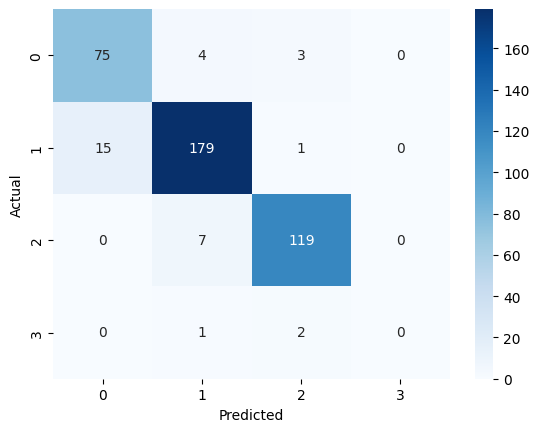

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()